# 1. Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# 2. Load dataset

In [3]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


# 3. Visualize Images

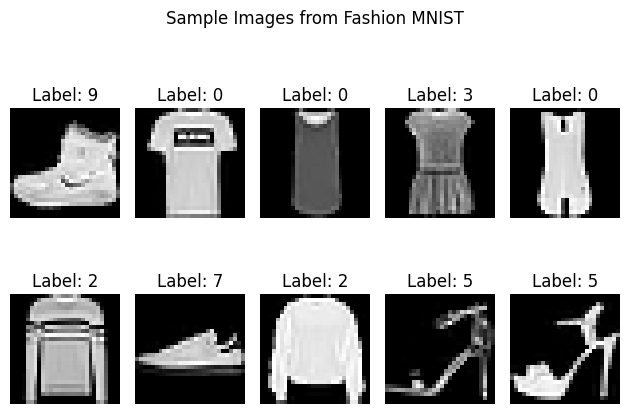

In [4]:
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.suptitle("Sample Images from Fashion MNIST")
plt.tight_layout()
plt.show()

# 5. Normalize Data

In [5]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


# 6. Model Building

### Reshaping because convolution operates on images with channel information.

In [6]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [7]:
X_train.shape

(60000, 28, 28, 1)

In [8]:
model = Sequential([

    # 1. Convolution Layer
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),

    # 2. Max Pooling Layer
    MaxPooling2D(pool_size=(2, 2)),

    # 3. Flatten Layer
    Flatten(),

    # 4. Dense Hidden Layer
    Dense(128, activation='relu'),

    # 5. Output Layer
    Dense(10, activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.8551 - loss: 0.4079 - val_accuracy: 0.8860 - val_loss: 0.3152
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.9001 - loss: 0.2752 - val_accuracy: 0.9037 - val_loss: 0.2704
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.9170 - loss: 0.2284 - val_accuracy: 0.9058 - val_loss: 0.2659
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.9295 - loss: 0.1915 - val_accuracy: 0.9119 - val_loss: 0.2460
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.9406 - loss: 0.1631 - val_accuracy: 0.9160 - val_loss: 0.2427
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.9491 - loss: 0.1388 - val_accuracy: 0.9074 - val_loss: 0.2705
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.9565 - loss: 0.1163 - val_accuracy: 0.9127 - val_loss: 0.2739
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 23ms/step - accuracy: 0.9636 -

# 7 Model Evaluation

### Testing Accuracy

In [13]:
test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9152 - loss: 0.3243
Test Accuracy: [0.32429227232933044, 0.9151999950408936]


### Trainging Accuracy

In [15]:
print(history.history["accuracy"])

[0.8550624847412109, 0.9001458287239075, 0.917020857334137, 0.929520845413208, 0.940583348274231, 0.9491041898727417, 0.9565416574478149, 0.9636250138282776, 0.9702916741371155, 0.9752083420753479]


### Loss

In [16]:
train_loss = history.history["loss"]
print(f"Training Loss: {train_loss}")

Training Loss: [0.40788957476615906, 0.27520444989204407, 0.22841672599315643, 0.19150254130363464, 0.16314339637756348, 0.13884718716144562, 0.11634249985218048, 0.09863677620887756, 0.08283690363168716, 0.06855247169733047]


In [17]:
predictions = model.predict(X_test[:10])
predicted_labels = np.argmax(predictions, axis=1)

print("Predicted Labels:")
print(predicted_labels)

print("\nActual Labels:")
print(y_test[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
Predicted Labels:
[9 2 1 1 6 1 4 6 5 7]

Actual Labels:
[9 2 1 1 6 1 4 6 5 7]
